In [130]:
import numpy as np
import matplotlib.pyplot as plt
import pathlib
from ttn_project.calc.orca_parser import get_anharmonic_constants, get_dipole_moment_1
from Experiment.utils import get_orbitals_indices_first
from utils_H2O import random_mps_h2o_harmonic_oscillator_0
from H2O_ttno import get_ttno_h2o
from CheTTNS_A_B import *
from pytreenet.core import Node
from pytreenet.ttns import TreeTensorNetworkState
from pytreenet.ttno import TreeTensorNetworkOperator
from pytreenet.random import crandn
from pytreenet.core import Node
from pytreenet.ttns import TreeTensorNetworkState
from pytreenet.ttno import TreeTensorNetworkOperator
from pytreenet.random import random_tensor_node, crandn
from pytreenet.operators.models.two_site_model import XYModel
from pytreenet.operators.common_operators import *
from Dipole_moment import get_mu_ttno_linear
import scipy.sparse as sp

In [131]:
def apply_ttno_by_method(ttns, ttno, method, svd_params, seed=None):
    """Apply TTNO to TTNS with one of the contraction/truncation methods."""
    if method == ApplicationMethod.SRC:
        return apply_ttno_to_ttns(
            ttns=ttns,
            ttno=ttno,
            method=method,
            desired_dimension=int(svd_params.max_bond_dim),
            seed=seed,
        )
    if method == ApplicationMethod.DIRECT_TRUNCATE:
        return apply_ttno_to_ttns(
            ttns=ttns,
            ttno=ttno,
            method=method,
            params=svd_params,
        )
    return apply_ttno_to_ttns(
        ttns=ttns,
        ttno=ttno,
        method=method,
        svd_params=svd_params,
    )


def cheb_ttns_CBC(v_ket: TreeTensorNetworkState,
              H_scaled: TreeTensorNetworkOperator,
              shift: float,
              N: int,
              svd_params: SVDParameters,
              application_method=ApplicationMethod.HALF_DENSITY_MATRIX,
              seed=20260527,
              num_sweeps= 2,
              dtype=np.float64,
              ):
    phi_initial = copy.deepcopy(v_ket)
    psi_list = [phi_initial]

    if N > 1:
        Hpsi0 = apply_ttno_by_method(
            psi_list[0],
            H_scaled,
            method=application_method,
            svd_params=svd_params,
            seed=seed,
        )
        psi1 = linear_combination([Hpsi0, psi_list[0]], [1.0, -shift], svd_params.max_bond_dim, num_sweeps, dtype=dtype)
        psi_list.append(psi1)

    for n in range(1, N-1):
        Hpsin = apply_ttno_by_method(
            psi_list[n],
            H_scaled,
            method=application_method,
            svd_params=svd_params,
            seed=None if seed is None else seed + n,
        )
        Hprime = linear_combination([Hpsin, psi_list[n]], [1.0, -shift], svd_params.max_bond_dim, num_sweeps, dtype=dtype)
        psi_np1 = linear_combination([Hprime, psi_list[n-1]], [2.0, -1.0], svd_params.max_bond_dim, num_sweeps, dtype=dtype)
        psi_list.append(psi_np1)

    return psi_list


In [132]:
def rescale_Matrix_new(H, W_prime=0.9875):
    # smallest eigenvalue
    e_min, v_min = eigsh(H, k=1, which='SA')
    E_min = e_min[0]
    psi_min = v_min[:, 0]

    # largest eigenvalue
    e_max, v_max = eigsh(H, k=1, which='LA')
    E_max = e_max[0]
    psi_max = v_max[:, 0]

    # rescaling
    a = (E_max - E_min) / (2.0 * W_prime)
    b = E_min + a * W_prime

    I = sp.eye(H.shape[0], format=H.format if sp.issparse(H) else None)

    H_scaled = np.asarray((H - b * I) / a)

    return H_scaled, a, E_min, psi_min

In [133]:
def poles_and_weights_all(Heff, psi0_eff, a, hermitian=False):
    
    Heff = np.asarray(Heff)
    psi0_eff = np.asarray(psi0_eff)

    # Diagonalize Heff
    if hermitian:
        evals, evecs = np.linalg.eigh(Heff)
    else:
        evals, evecs = np.linalg.eig(Heff)

    # Sort by eigenvalue (optional but convenient for plotting)
    idx = np.argsort(evals.real)
    evals = evals[idx]
    evecs = evecs[:, idx]

    # Weights: Omega_n = |<phi_n | 0_eff>|^2 / a
    overlaps = evecs.conj().T @ psi0_eff
    weights = (np.abs(overlaps) ** 2) / a

    # Poles = eigenvalues (usually take real part for plotting)
    poles = evals.real

    return poles, weights

In [134]:
def merge_close_poles(poles_x, weights_x, poles_y, weights_y, tol=1e-6, weighted_pos=False):
    poles_x = np.asarray(poles_x)
    poles_y = np.asarray(poles_y)
    weights_x = np.asarray(weights_x)
    weights_y = np.asarray(weights_y)

    poles_all = np.concatenate([poles_x, poles_y])
    weights_all = np.concatenate([weights_x, weights_y])

    idx = np.argsort(poles_all)
    poles_all = poles_all[idx]
    weights_all = weights_all[idx]

    merged_poles = []
    merged_weights = []

    current_poles = [poles_all[0]]
    current_weights = [weights_all[0]]

    for p, w in zip(poles_all[1:], weights_all[1:]):
        if abs(p - current_poles[-1]) <= tol:
            current_poles.append(p)
            current_weights.append(w)
        else:
            current_poles = np.array(current_poles)
            current_weights = np.array(current_weights)

            if weighted_pos and np.sum(current_weights) > 0:
                merged_poles.append(np.average(current_poles, weights=current_weights))
            else:
                merged_poles.append(np.mean(current_poles))

            merged_weights.append(np.sum(current_weights))

            current_poles = [p]
            current_weights = [w]

    current_poles = np.array(current_poles)
    current_weights = np.array(current_weights)

    if weighted_pos and np.sum(current_weights) > 0:
        merged_poles.append(np.average(current_poles, weights=current_weights))
    else:
        merged_poles.append(np.mean(current_poles))

    merged_weights.append(np.sum(current_weights))

    return np.array(merged_poles), np.array(merged_weights)

### CH3CN Hamiltonian

In [135]:
N = [13, 13, 13]
node_order = [0, 1, 2]
f = pathlib.Path("ttn_project/orca/h2o/vib")

omega, _, _ = get_anharmonic_constants(
    f,
    map_modes=[0, 1, 2],
    signs=[1, 1, 1],
)

omega = np.array(omega, dtype=np.float64) / 1000.0

_, orb_state, orb_Es = get_orbitals_indices_first(
    omega,
    num_orb=1,
)

state0 = random_mps_h2o_harmonic_oscillator_0(
    physical_dim=N,
    omega=omega,
    orb_state=orb_state[0].reshape(1, -1),
)

state0.canonical_form(state0.root_id)

ttno, _ = get_ttno_h2o(
    N=N,
    state=state0,
    hamiltonian=True,
)

site_ids = list(state0.nodes.keys())
print("Number of sites:", len(site_ids))
print("Site ids:", site_ids)
print("orb_state:", orb_state[0])
print("orb_E:", orb_Es[0])

Number of sites: 3
Site ids: ['site0', 'site1', 'site2']
orb_state: [0 0 0]
orb_E: 4.644214199


In [136]:
H_matrix = ttno.as_matrix()
print(H_matrix[0])

from scipy.sparse.linalg import eigsh

Emin,_ = np.linalg.eig(H_matrix[0])


print(Emin[0])
print(Emin[-1])

[[ 72.05532181  -4.34465172   0.58158188 ...   0.           0.
    0.        ]
 [ -4.34465172  65.21908207  -6.37907023 ...   0.           0.
    0.        ]
 [  0.58158188  -6.37907023  62.0092245  ...   0.           0.
    0.        ]
 ...
 [  0.           0.           0.         ... 107.5370414   -6.37907023
    0.58158188]
 [  0.           0.           0.         ...  -6.37907023 122.38391552
   -4.34465172]
 [  0.           0.           0.         ...   0.58158188  -4.34465172
  146.6573484 ]]
160.89882477756234
56.366499047274075


In [137]:
Emin
Emin_sort = np.sort(Emin)
print("Emin_sort", Emin_sort)

Emin_sort [  4.64050739   6.24215613   7.8235987  ... 158.36669    159.28340189
 160.89882478]


In [138]:
Emin_real = Emin_sort- Emin_sort[0]
print("Emin_real", Emin_real)
print(Emin_real[:5])

Emin_real [  0.           1.60164873   3.18309131 ... 153.72618261 154.64289449
 156.25831739]
[0.         1.60164873 3.18309131 3.69277854 3.92572319]


### Construct dipole moment

In [139]:
dipole_moment = np.asarray(get_dipole_moment_1(f), dtype=np.float64)

print("dipole_moment:")
print(dipole_moment)

dmu_dx = dipole_moment[:, 0]
dmu_dy = dipole_moment[:, 1]
dmu_dz = dipole_moment[:, 2]

mu_x_ttno= get_mu_ttno_linear(
    N=N,
    state=state0,
    dipole_derivative=dmu_dx
)

mu_y_ttno = get_mu_ttno_linear(
    N=N,
    state=state0,
    dipole_derivative=dmu_dy
)


print("mu_x TTNO bond dims:", mu_x_ttno.bond_dims())
print("mu_y TTNO bond dims:", mu_y_ttno.bond_dims())

dipole_moment:
[[ 0.        0.054297 -0.      ]
 [-0.        0.008175 -0.      ]
 [ 0.031032  0.        0.      ]]
mu_x TTNO bond dims: {('site0', 'site1'): 1, ('site1', 'site2'): 1}
mu_y TTNO bond dims: {('site0', 'site1'): 2, ('site1', 'site2'): 1}


### Rescale Hamiltonian

In [140]:
H_scaled, a, shift, E_min, E_max, psi_min = rescale_TTNO(state0, ttno)
print("E_min:", E_min)
print("E_max:", E_max)
psi_min.normalise()
E_min_rescaled, E_max_rescaled, _ = dmrg_min_max(state0, H_scaled)
print("E_min_rescale:", E_min_rescaled - shift)
print("E_max_rescale:", E_max_rescaled - shift)

E_min: 4.642361405099323
E_max: 160.89771619277556
E_min_rescale: -0.9874999999998624
E_max_rescale: 0.9555002255891885


### Compute bra and ket ttns

In [141]:
svd_params = SVDParameters(max_bond_dim=12, rel_tol=0.0, total_tol=0.0, sum_trunc=False)

# Change this one line to test a single contraction method in the original workflow.
# The comparison section at the end of the notebook loops over all five methods.
application_method = ApplicationMethod.HALF_DENSITY_MATRIX

psi_ket_x = copy.deepcopy(psi_min)
psi_ket_x = apply_ttno_by_method(
    psi_ket_x,
    mu_x_ttno,
    method=application_method,
    svd_params=svd_params,
    seed=20260527,
)
psi_bra_x = copy.deepcopy(psi_ket_x)

psi_ket_y = copy.deepcopy(psi_min)
psi_ket_y = apply_ttno_by_method(
    psi_ket_y,
    mu_y_ttno,
    method=application_method,
    svd_params=svd_params,
    seed=20260528,
)
psi_bra_y = copy.deepcopy(psi_ket_y)


### Computing Chebyshev TTNS

In [142]:
ttns_list_x_real = cheb_ttns_CBC(psi_ket_x, H_scaled, shift=shift, N=300, svd_params=svd_params, application_method=application_method, seed=20260529)
print(len(ttns_list_x_real))

mu_x = chebyshev_moments_ttns(psi_bra_x, ttns_list_x_real)
print(len(mu_x))

300
300


In [143]:
ttns_list_y_real = cheb_ttns_CBC(psi_ket_y, H_scaled, shift=shift, N=300, svd_params=svd_params, application_method=application_method, seed=20260530)
print(len(ttns_list_y_real))

mu_y = chebyshev_moments_ttns(psi_bra_y, ttns_list_y_real)
print(len(mu_y))

300
300


## Effective

In [144]:
ttns_list_x = cheb_ttns_CBC(psi_ket_x, H_scaled, shift=shift, N=6, svd_params=svd_params, application_method=application_method, seed=20260531)
print(len(ttns_list_x))

6


In [145]:
ttns_list_y = cheb_ttns_CBC(psi_ket_y, H_scaled, shift=shift, N=6, svd_params=svd_params, application_method=application_method, seed=20260532)
print(len(ttns_list_y))

6


In [146]:
ttns_list_y = cheb_ttns_CBC(psi_ket_y, H_scaled, shift=shift, N=6, svd_params=svd_params, application_method=application_method, seed=20260533)
print(len(ttns_list_y))

6


In [147]:
C_x, ovp_x = canonical_ttns(ttns_list_x, eig_cut=1e-14)

I_eff = C_x.conj().T @ ovp_x @ C_x
print("||I_eff_mat - I||_F =", np.linalg.norm(I_eff - np.eye(I_eff.shape[0]), 'fro'))

||I_eff_mat - I||_F = 3.358188167386661e-09


In [148]:
C_y, ovp_y = canonical_ttns(ttns_list_y, eig_cut=1e-14)

I_eff = C_y.conj().T @ ovp_y @ C_y
print("||I_eff_mat - I||_F =", np.linalg.norm(I_eff - np.eye(I_eff.shape[0]), 'fro'))

||I_eff_mat - I||_F = 1.4443337298181416e-08


### Heff

In [149]:
Heff_x = heff_ttns(ttns_list_x, C_x, H_scaled, shift)
print(Heff_x.shape)

(4, 4)


In [150]:
Heff_y = heff_ttns(ttns_list_y, C_y, H_scaled, shift)
print(Heff_y.shape)

(4, 4)


In [151]:
from scipy.sparse.linalg import eigsh

Emin_x = eigsh(Heff_x, k=1, which='SA',
             return_eigenvectors=False)[0]

Emax_x = eigsh(Heff_x, k=1, which='LA',
             return_eigenvectors=False)[0]

Emin_y = eigsh(Heff_y, k=1, which='SA',
             return_eigenvectors=False)[0]

Emax_y = eigsh(Heff_y, k=1, which='LA',
             return_eigenvectors=False)[0]

print("Emin_x:", Emin_x)
print("Emax_x:", Emax_x)
print("Emin_y:", Emin_y)
print("Emax_y:", Emax_y)

Emin_x: -0.9379019154979281
Emax_x: -0.6763133087409305
Emin_y: -0.9672829294756461
Emax_y: -0.7687499862557854


### Computing bra and ket vector

In [152]:
v_ket_x = psi_eff_ttns(ttns_list_x, C_x, psi_ket_x)
print(len(v_ket_x))
v_bra_x = psi_eff_ttns(ttns_list_x, C_x, psi_bra_x)
print(len(v_bra_x))

v_ket_y = psi_eff_ttns(ttns_list_y, C_y, psi_ket_y)
print(len(v_ket_y))
v_bra_y = psi_eff_ttns(ttns_list_y, C_y, psi_bra_y)
print(len(v_bra_y))

4
4
4
4


### Effective chebyshev vectors

In [153]:
coChe_vec_list_x = cheb_vector(Heff_x, N= 6000, v_ket=v_ket_x)
print(len(coChe_vec_list_x))
coChe_vec_list_y = cheb_vector(Heff_y, N= 6000, v_ket=v_ket_y)
print(len(coChe_vec_list_y))

6000
6000


### Effective chebyshev moments

In [154]:
mu_eff_x = chebyshev_moments_vector(v_bra_x, coChe_vec_list_x)
print(len(mu_eff_x))
mu_eff_y = chebyshev_moments_vector(v_bra_y, coChe_vec_list_y)
print(len(mu_eff_y))

6000
6000


### Poles 

In [155]:
W_prime= 0.9875
poles_x, weights_x = poles_and_weights_all(Heff=Heff_x, psi0_eff=v_ket_x, a=a)
poles_y, weights_y = poles_and_weights_all(Heff=Heff_y, psi0_eff=v_ket_y, a=a)
poles, weights = merge_close_poles(poles_x, weights_x, poles_y, weights_y, tol=1e-6)
E_poles = a * (poles + W_prime)


n = 5.0
mask = E_poles <= n
poles = poles[mask]
weights = weights[mask]
E_poles = a * (poles + W_prime)

print("weights:", weights)
print("E_poles:", E_poles)


weights: [1.88486570e-05 4.26998060e-07 5.97830902e-06]
E_poles: [1.5995066  3.7177639  3.92403356]


## Matrix Method

In [156]:
from ttn_project.calc.example import construct_hamiltonian, to_matrix, construct_dipole_moment1
h, w, cubic, quartic = construct_hamiltonian(6, f)
h = to_matrix(h)

dx, dy, dz = construct_dipole_moment1(6, f)

print("w", w)


w [1.62282508 3.78232774 3.88327558]


### Rescale Matrix

In [157]:
H_scaled_mat, a_mat, E_min_mat, psi_min_mat = rescale_Matrix_new(h)
print("E_min:", E_min_mat)


v_x = np.asarray(to_matrix(dx) @ psi_min_mat).reshape(-1)
v_y = np.asarray(to_matrix(dy) @ psi_min_mat).reshape(-1)

print("H_scaled_mat shape:", H_scaled_mat.shape)
print(len(v_x))
print(len(v_y))

E_min: 4.640507389801061
H_scaled_mat shape: (2197, 2197)
2197
2197


In [158]:
emin, _ = eigsh(H_scaled_mat, k=1, which='SA')
emax,_ = eigsh(H_scaled_mat, k=1, which='LA')
print("emin:", emin)
print("emax:", emax)

emin: [-0.9875]
emax: [0.9875]


In [159]:
vec_list_x = cheb_vector(H_scaled_mat, N= 6000, v_ket=v_x)
mu_mat_x = chebyshev_moments_vector(v_x, vec_list_x)

vec_list_y = cheb_vector(H_scaled_mat, N= 6000, v_ket=v_y)
mu_mat_y = chebyshev_moments_vector(v_y, vec_list_y)

print(len(mu_mat_x))
print(len(mu_mat_y))

6000
6000


# Comparing

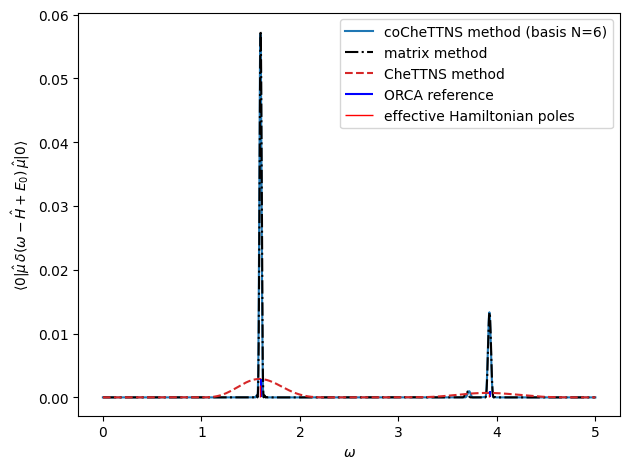

In [160]:
E_max = 5
W_prime= 0.9875
x_max = E_max/a - W_prime
x_grid = np.linspace(-0.9875, min(0.999, x_max), 1600)
E_grid = a * (x_grid + W_prime)
E_grid_matrix = a_mat * (x_grid + W_prime)

orca_freq = np.array([1.60164873, 3.69277854, 3.92572319]) 

orca_int = np.array([0.002948, 0.000067, 0.000963])


vals_ttns = []

for x in x_grid:
    A_x = reconstruct_delta_spectrum(x=x, mu=mu_x, a=a)
    A_y = reconstruct_delta_spectrum(x=x, mu=mu_y, a=a)
    vals_ttns.append(A_x+A_y)


vals_ttns = np.array(vals_ttns)


vals_ttns_eff = []

for x in x_grid:
    A_x = reconstruct_delta_spectrum(x=x, mu=mu_eff_x, a=a)
    A_y = reconstruct_delta_spectrum(x=x, mu=mu_eff_y, a=a)
    vals_ttns_eff.append(A_x+A_y)


vals_ttns_eff = np.array(vals_ttns_eff)


vals_mat = []
for x in x_grid:
    A_x = reconstruct_delta_spectrum(x=x, mu=mu_mat_x, a=a_mat)
    A_y = reconstruct_delta_spectrum(x=x, mu=mu_mat_y, a=a_mat)
    vals_mat.append(A_x+A_y)

vals_mat = np.array(vals_mat)


plt.figure()


plt.plot(
    E_grid,
    vals_ttns_eff,
    color="tab:blue",
    linestyle="-",
    label="coCheTTNS method (basis N=6)"
)

plt.plot(
    E_grid_matrix,
    vals_mat,
    color="black",
    linestyle="-.",
    label="matrix method"
)

plt.plot(
    E_grid,
    vals_ttns,
    color="tab:red",
    linestyle="--",
    label="CheTTNS method"
)

plt.vlines(orca_freq, 0, orca_int, color="blue",linestyle="-", label="ORCA reference")

scale = 100
plt.vlines(E_poles, 0, scale * weights, color="red", linewidth=1, label="effective Hamiltonian poles")

plt.xlabel(r"$\omega$")
plt.ylabel(r"$\langle 0|\hat{\mu}\,\delta(\omega-\hat{H}+E_0)\,\hat{\mu}|0\rangle$")
plt.legend()
plt.tight_layout()
plt.savefig("h2o_cochet_ttns_basis6_vs_matrix.png", dpi=180, bbox_inches="tight")
plt.show()

## CoChebyshev TTNS

In [161]:
from scipy.signal import find_peaks
peaks, _ = find_peaks(vals_ttns_eff)

In [162]:
x0 = 1.60164873
window = 0.05  

mask = (E_grid >= x0 - window) & (E_grid <= x0 + window)
local_indices = np.where(mask)[0]

peak_idx = local_indices[np.argmax(vals_ttns_eff[local_indices])]

left = peak_idx
while left > 0 and vals_ttns_eff[left-1] <= vals_ttns_eff[left]:
    left -= 1

right = peak_idx
while right < len(vals_ttns_eff)-1 and vals_ttns_eff[right+1] <= vals_ttns_eff[right]:
    right += 1

T2_peak = np.trapz(vals_ttns_eff[left:right+1], E_grid[left:right+1]) * 2
error = abs(T2_peak - 0.002948) / 0.002948 * 100

print("input x0:", x0)
print("actual peak x:", E_grid[peak_idx])
print("integration range:", E_grid[left], E_grid[right])
print("T2 peak:", T2_peak)
print("error (%):", error)

input x0: 1.60164873
actual peak x: 1.60100062539087
integration range: 1.5666041275797422 1.6322701688555339
T2 peak: 0.002967598205341286
error (%): 0.6647966533679134


/var/folders/fn/w6qty04x2gdcczl9bs6bz0lc0000gn/T/ipykernel_81566/2905828797.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  T2_peak = np.trapz(vals_ttns_eff[left:right+1], E_grid[left:right+1]) * 2


In [163]:
x0 = 3.69277854
window = 0.05  

mask = (E_grid >= x0 - window) & (E_grid <= x0 + window)
local_indices = np.where(mask)[0]

peak_idx = local_indices[np.argmax(vals_ttns_eff[local_indices])]

left = peak_idx
while left > 0 and vals_ttns_eff[left-1] <= vals_ttns_eff[left]:
    left -= 1

right = peak_idx
while right < len(vals_ttns_eff)-1 and vals_ttns_eff[right+1] <= vals_ttns_eff[right]:
    right += 1

T2_peak = np.trapz(vals_ttns_eff[left:right+1], E_grid[left:right+1]) * 2
error = abs(T2_peak - 0.000067) / 0.000067 * 100

print("input x0:", x0)
print("actual peak x:", E_grid[peak_idx])
print("integration range:", E_grid[left], E_grid[right])
print("T2 peak:", T2_peak)
print("error (%):", error)

input x0: 3.69277854
actual peak x: 3.7179487179487176
integration range: 3.67417135709819 3.761726078799254
T2 peak: 6.726064932675704e-05
error (%): 0.3890288459060248


/var/folders/fn/w6qty04x2gdcczl9bs6bz0lc0000gn/T/ipykernel_81566/3826453450.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  T2_peak = np.trapz(vals_ttns_eff[left:right+1], E_grid[left:right+1]) * 2


In [164]:
x0 = 3.92572319
window = 0.05  

mask = (E_grid >= x0 - window) & (E_grid <= x0 + window)
local_indices = np.where(mask)[0]

peak_idx = local_indices[np.argmax(vals_ttns_eff[local_indices])]

left = peak_idx
while left > 0 and vals_ttns_eff[left-1] <= vals_ttns_eff[left]:
    left -= 1

right = peak_idx
while right < len(vals_ttns_eff)-1 and vals_ttns_eff[right+1] <= vals_ttns_eff[right]:
    right += 1

T2_peak = np.trapz(vals_ttns_eff[left:right+1], E_grid[left:right+1]) * 2
sum_peak = 0.000963
error = abs(T2_peak - sum_peak) / sum_peak * 100

print("input x0:", x0)
print("actual peak x:", E_grid[peak_idx])
print("integration range:", E_grid[left], E_grid[right])
print("T2 peak:", T2_peak)
print("error (%):", error)

input x0: 3.92572319
actual peak x: 3.9243277048155107
integration range: 3.8805503439649827 3.9681050656660473
T2 peak: 0.0009412002302188136
error (%): 2.2637351797701304


/var/folders/fn/w6qty04x2gdcczl9bs6bz0lc0000gn/T/ipykernel_81566/1673034697.py:17: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  T2_peak = np.trapz(vals_ttns_eff[left:right+1], E_grid[left:right+1]) * 2


## Matrix

In [165]:
peaks_mat, _ = find_peaks(vals_mat)

### First peak

In [166]:
peak_name = "peak1"
left_hint = 1.5
right_hint = 1.7

mask = (E_grid_matrix >= left_hint) & (E_grid_matrix <= right_hint)
local_indices = np.where(mask)[0]

peak_idx = local_indices[np.argmax(vals_mat[local_indices])]

left = peak_idx
while left > 0 and vals_mat[left-1] <= vals_mat[left]:
    left -= 1

right = peak_idx
while right < len(vals_mat)-1 and vals_mat[right+1] <= vals_mat[right]:
    right += 1

matrix_peak_area = np.trapz(vals_mat[left:right+1], E_grid_matrix[left:right+1]) * 2

print("matrix peak:", peak_name)
print("search range:", left_hint, right_hint)
print("actual matrix peak x:", E_grid_matrix[peak_idx])
print("integration range:", E_grid_matrix[left], E_grid_matrix[right])
print("matrix peak area:", matrix_peak_area)


matrix peak: peak1
search range: 1.5 1.7
actual matrix peak x: 1.6010309892919337
integration range: 1.569760852782327 1.6323011258015403
matrix peak area: 0.002970471051613529


/var/folders/fn/w6qty04x2gdcczl9bs6bz0lc0000gn/T/ipykernel_81566/2654160313.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  matrix_peak_area = np.trapz(vals_mat[left:right+1], E_grid_matrix[left:right+1]) * 2


### Second peak

In [167]:
peak_name = "peak2"
left_hint = 3.62
right_hint = 3.76

mask = (E_grid_matrix >= left_hint) & (E_grid_matrix <= right_hint)
local_indices = np.where(mask)[0]

peak_idx = local_indices[np.argmax(vals_mat[local_indices])]

left = peak_idx
while left > 0 and vals_mat[left-1] <= vals_mat[left]:
    left -= 1

right = peak_idx
while right < len(vals_mat)-1 and vals_mat[right+1] <= vals_mat[right]:
    right += 1

matrix_peak_area = np.trapz(vals_mat[left:right+1], E_grid_matrix[left:right+1]) * 2

print("matrix peak:", peak_name)
print("search range:", left_hint, right_hint)
print("actual matrix peak x:", E_grid_matrix[peak_idx])
print("integration range:", E_grid_matrix[left], E_grid_matrix[right])
print("matrix peak area:", matrix_peak_area)


matrix peak: peak2
search range: 3.62 3.76
actual matrix peak x: 3.693003121784717
integration range: 3.6492249306712607 3.736781312898165
matrix peak area: 6.643596518045152e-05


/var/folders/fn/w6qty04x2gdcczl9bs6bz0lc0000gn/T/ipykernel_81566/1609536276.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  matrix_peak_area = np.trapz(vals_mat[left:right+1], E_grid_matrix[left:right+1]) * 2


### Third peak

In [168]:
peak_name = "peak3"
left_hint = 3.86
right_hint = 4.0

mask = (E_grid_matrix >= left_hint) & (E_grid_matrix <= right_hint)
local_indices = np.where(mask)[0]

peak_idx = local_indices[np.argmax(vals_mat[local_indices])]

left = peak_idx
while left > 0 and vals_mat[left-1] <= vals_mat[left]:
    left -= 1

right = peak_idx
while right < len(vals_mat)-1 and vals_mat[right+1] <= vals_mat[right]:
    right += 1

matrix_peak_area = np.trapz(vals_mat[left:right+1], E_grid_matrix[left:right+1]) * 2

print("matrix peak:", peak_name)
print("search range:", left_hint, right_hint)
print("actual matrix peak x:", E_grid_matrix[peak_idx])
print("integration range:", E_grid_matrix[left], E_grid_matrix[right])
print("matrix peak area:", matrix_peak_area)


matrix peak: peak3
search range: 3.86 4.0
actual matrix peak x: 3.9244021319558136
integration range: 3.883750954493324 3.96818032306927
matrix peak area: 0.0009450257227446545


/var/folders/fn/w6qty04x2gdcczl9bs6bz0lc0000gn/T/ipykernel_81566/1207587281.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  matrix_peak_area = np.trapz(vals_mat[left:right+1], E_grid_matrix[left:right+1]) * 2


In [169]:
# Matrix-section peak references used below.
# These are computed from vals_mat/E_grid_matrix, not from ORCA frequencies.
MATRIX_PEAK_SEARCH_WINDOWS = [
    ("peak1", 1.50, 1.70),
    ("peak2", 3.62, 3.76),
    ("peak3", 3.86, 4.00),
]

def matrix_section_peak_area(vals, energy_grid, left_hint, right_hint):
    local_indices = np.where((energy_grid >= left_hint) & (energy_grid <= right_hint))[0]
    peak_idx = local_indices[np.argmax(vals[local_indices])]
    left = peak_idx
    while left > 0 and vals[left - 1] <= vals[left]:
        left -= 1
    right = peak_idx
    while right < len(vals) - 1 and vals[right + 1] <= vals[right]:
        right += 1
    return {
        "peak_x": float(energy_grid[peak_idx]),
        "area": float(np.trapz(vals[left:right + 1], energy_grid[left:right + 1]) * 2.0),
        "left_x": float(energy_grid[left]),
        "right_x": float(energy_grid[right]),
        "search_left_x": float(left_hint),
        "search_right_x": float(right_hint),
    }

matrix_peak_ref = {
    peak_name: matrix_section_peak_area(vals_mat, E_grid_matrix, left_hint, right_hint)
    for peak_name, left_hint, right_hint in MATRIX_PEAK_SEARCH_WINDOWS
}

print_table_rows = []
for peak_name, ref in matrix_peak_ref.items():
    print_table_rows.append((peak_name, ref["peak_x"], ref["area"], ref["left_x"], ref["right_x"]))
for row in print_table_rows:
    print(f"{row[0]}: peak_x={row[1]:.8f}, area={row[2]:.10g}, range=[{row[3]:.8f}, {row[4]:.8f}]")


peak1: peak_x=1.60103099, area=0.002970471052, range=[1.56976085, 1.63230113]
peak2: peak_x=3.69300312, area=6.643596518e-05, range=[3.64922493, 3.73678131]
peak3: peak_x=3.92440213, area=0.0009450257227, range=[3.88375095, 3.96818032]


/var/folders/fn/w6qty04x2gdcczl9bs6bz0lc0000gn/T/ipykernel_81566/1267596813.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  "area": float(np.trapz(vals[left:right + 1], energy_grid[left:right + 1]) * 2.0),


## CoCheTTNS Contraction And Orthogonalization Comparison

This section compares TTNO -> TTNS contraction methods and the CoCheTTNS orthogonalization choice.
The reference values are the local peak areas from the matrix method.


In [170]:
import copy
import time
from pytreenet.ttns.ttns_ttno.application import ApplicationMethod, apply_ttno_to_ttns
from pytreenet.util import SVDParameters
from pytreenet.util.misc_functions import linear_combination

CONTRACTION_METHODS = [
    ("zipup", "Zipup", ApplicationMethod.ZIPUP),
    ("direct_truncate", "Direct+Truncate", ApplicationMethod.DIRECT_TRUNCATE),
    ("density_matrix", "Density Matrix", ApplicationMethod.DENSITY_MATRIX),
    ("half_density_matrix", "Half Density Matrix", ApplicationMethod.HALF_DENSITY_MATRIX),
    ("src", "SRC", ApplicationMethod.SRC),
]

ORTHOGONALIZATION_METHODS = [
    ("canonical", "canonical_ttns", canonical_ttns),
    ("cholesky", "cholesky_ttns", cholesky_ttns),
]

# Broad search intervals only. The reference peak positions and areas are computed
# from vals_mat in the Matrix section, not from ORCA/input frequencies.
MATRIX_PEAK_SEARCH_WINDOWS = [
    ("peak1", 1.50, 1.70),
    ("peak2", 3.62, 3.76),
    ("peak3", 3.86, 4.00),
]

class TTNOApplier:
    def __init__(self, method, svd_params, seed=20260527):
        self.method = method
        self.svd_params = svd_params
        self.seed = seed
        self.calls = 0

    def apply(self, ttns, ttno):
        if self.method == ApplicationMethod.SRC:
            self.calls += 1
            return apply_ttno_to_ttns(
                ttns=ttns,
                ttno=ttno,
                method=self.method,
                desired_dimension=int(self.svd_params.max_bond_dim),
                seed=self.seed + self.calls,
            )
        if self.method == ApplicationMethod.DIRECT_TRUNCATE:
            return apply_ttno_to_ttns(
                ttns=ttns,
                ttno=ttno,
                method=self.method,
                params=self.svd_params,
            )
        return apply_ttno_to_ttns(
            ttns=ttns,
            ttno=ttno,
            method=self.method,
            svd_params=self.svd_params,
        )

def cheb_ttns_by_application_method(v_ket, H_scaled, shift, N, svd_params, applier, num_sweeps=2, dtype=np.float64):
    psi_list = [copy.deepcopy(v_ket)]
    if N > 1:
        Hpsi0 = applier.apply(psi_list[0], H_scaled)
        psi1 = linear_combination(
            [Hpsi0, psi_list[0]],
            [1.0, -shift],
            svd_params.max_bond_dim,
            num_sweeps,
            dtype=dtype,
        )
        psi_list.append(psi1)
    for n in range(1, N - 1):
        Hpsin = applier.apply(psi_list[n], H_scaled)
        Hprime = linear_combination(
            [Hpsin, psi_list[n]],
            [1.0, -shift],
            svd_params.max_bond_dim,
            num_sweeps,
            dtype=dtype,
        )
        psi_np1 = linear_combination(
            [Hprime, psi_list[n - 1]],
            [2.0, -1.0],
            svd_params.max_bond_dim,
            num_sweeps,
            dtype=dtype,
        )
        psi_list.append(psi_np1)
    return psi_list

def spectrum_from_moments(mu_x, mu_y, x_grid, a):
    return np.array([
        reconstruct_delta_spectrum(x=x, mu=mu_x, a=a)
        + reconstruct_delta_spectrum(x=x, mu=mu_y, a=a)
        for x in x_grid
    ])

def orthogonalization_diagnostics(C, ovp):
    I_eff = C.conj().T @ ovp @ C
    identity_err = float(np.linalg.norm(I_eff - np.eye(I_eff.shape[0]), 'fro'))
    projector_err = float(np.linalg.norm(I_eff @ I_eff - I_eff, 'fro'))
    active_dim = int(np.linalg.matrix_rank(I_eff, tol=1e-8))
    return I_eff, identity_err, projector_err, active_dim

def cochettns_spectrum_by_application_method(
    psi_min,
    mu_x_ttno,
    mu_y_ttno,
    H_scaled,
    shift,
    a,
    x_grid,
    method_enum,
    svd_params,
    orthogonalizer=canonical_ttns,
    orthogonalizer_name="canonical_ttns",
    basis_size=16,
    effective_moments=6000,
    eig_cut=1e-14,
    num_sweeps=2,
    seed=20260527,
):
    dipole_applier = TTNOApplier(method_enum, svd_params, seed=seed + 1000)
    x_applier = TTNOApplier(method_enum, svd_params, seed=seed + 2000)
    y_applier = TTNOApplier(method_enum, svd_params, seed=seed + 3000)

    psi_ket_x_method = dipole_applier.apply(copy.deepcopy(psi_min), mu_x_ttno)
    psi_bra_x_method = copy.deepcopy(psi_ket_x_method)
    psi_ket_y_method = dipole_applier.apply(copy.deepcopy(psi_min), mu_y_ttno)
    psi_bra_y_method = copy.deepcopy(psi_ket_y_method)

    ttns_list_x_method = cheb_ttns_by_application_method(
        psi_ket_x_method,
        H_scaled,
        shift,
        basis_size,
        svd_params,
        x_applier,
        num_sweeps=num_sweeps,
    )
    ttns_list_y_method = cheb_ttns_by_application_method(
        psi_ket_y_method,
        H_scaled,
        shift,
        basis_size,
        svd_params,
        y_applier,
        num_sweeps=num_sweeps,
    )

    C_x_method, ovp_x_method = orthogonalizer(ttns_list_x_method, eig_cut=eig_cut)
    C_y_method, ovp_y_method = orthogonalizer(ttns_list_y_method, eig_cut=eig_cut)
    _, identity_err_x, projector_err_x, active_dim_x = orthogonalization_diagnostics(C_x_method, ovp_x_method)
    _, identity_err_y, projector_err_y, active_dim_y = orthogonalization_diagnostics(C_y_method, ovp_y_method)

    Heff_x_method = heff_ttns(ttns_list_x_method, C_x_method, H_scaled, shift)
    Heff_y_method = heff_ttns(ttns_list_y_method, C_y_method, H_scaled, shift)

    v_ket_x_method = psi_eff_ttns(ttns_list_x_method, C_x_method, psi_ket_x_method)
    v_bra_x_method = psi_eff_ttns(ttns_list_x_method, C_x_method, psi_bra_x_method)
    v_ket_y_method = psi_eff_ttns(ttns_list_y_method, C_y_method, psi_ket_y_method)
    v_bra_y_method = psi_eff_ttns(ttns_list_y_method, C_y_method, psi_bra_y_method)

    coche_vec_list_x_method = cheb_vector(Heff_x_method, effective_moments, v_ket_x_method)
    coche_vec_list_y_method = cheb_vector(Heff_y_method, effective_moments, v_ket_y_method)

    mu_eff_x_method = chebyshev_moments_vector(v_bra_x_method, coche_vec_list_x_method)
    mu_eff_y_method = chebyshev_moments_vector(v_bra_y_method, coche_vec_list_y_method)
    vals_method = spectrum_from_moments(mu_eff_x_method, mu_eff_y_method, x_grid, a)

    return {
        "vals": vals_method,
        "mu_eff_x": mu_eff_x_method,
        "mu_eff_y": mu_eff_y_method,
        "orthogonalizer": orthogonalizer_name,
        "basis_dim_x": len(ttns_list_x_method),
        "basis_dim_y": len(ttns_list_y_method),
        "heff_dim_x": Heff_x_method.shape[0],
        "heff_dim_y": Heff_y_method.shape[0],
        "active_dim_x": active_dim_x,
        "active_dim_y": active_dim_y,
        "orth_identity_err_x": identity_err_x,
        "orth_identity_err_y": identity_err_y,
        "orth_projector_err_x": projector_err_x,
        "orth_projector_err_y": projector_err_y,
    }

def local_peak_area(vals, energy_grid, target_x, window):
    return local_peak_area_in_range(vals, energy_grid, target_x - window, target_x + window)


def local_peak_area_in_range(vals, energy_grid, left_hint, right_hint):
    local_indices = np.where((energy_grid >= left_hint) & (energy_grid <= right_hint))[0]
    if len(local_indices) == 0:
        raise ValueError(f"No grid points in [{left_hint}, {right_hint}]")
    peak_idx = local_indices[np.argmax(vals[local_indices])]
    left = peak_idx
    while left > 0 and vals[left - 1] <= vals[left]:
        left -= 1
    right = peak_idx
    while right < len(vals) - 1 and vals[right + 1] <= vals[right]:
        right += 1
    area = np.trapz(vals[left:right + 1], energy_grid[left:right + 1]) * 2.0
    return {
        "peak_x": float(energy_grid[peak_idx]),
        "area": float(area),
        "left_x": float(energy_grid[left]),
        "right_x": float(energy_grid[right]),
        "search_left_x": float(left_hint),
        "search_right_x": float(right_hint),
        "search_window": float(max(abs(float(energy_grid[peak_idx]) - left_hint), abs(right_hint - float(energy_grid[peak_idx])))),
    }

def print_table(rows, columns, title=None):
    if title is not None:
        print("\n" + title)
    str_rows = []
    for row in rows:
        str_row = []
        for col in columns:
            value = row.get(col, "")
            if isinstance(value, float):
                value = f"{value:.6g}"
            str_row.append(str(value))
        str_rows.append(str_row)
    widths = [len(col) for col in columns]
    for row in str_rows:
        widths = [max(width, len(value)) for width, value in zip(widths, row)]
    fmt = "  ".join("{:<" + str(width) + "}" for width in widths)
    print(fmt.format(*columns))
    print(fmt.format(*["-" * width for width in widths]))
    for row in str_rows:
        print(fmt.format(*row))


In [171]:
# Uses the variables already built above: psi_min, H_scaled, shift, a,
# mu_x_ttno, mu_y_ttno, x_grid, E_grid, E_grid_matrix, vals_mat.
# This compares the CoCheTTNS method: short TTNS basis -> Heff -> dense effective Chebyshev moments.
# N=16 gives a better effective subspace for the weak second peak while keeping the CoCheTTNS run small.

contraction_max_bond_dim = 12
cochet_basis_size = 16
cochet_effective_moments = 6000
cochet_eig_cut = 1e-14
contraction_num_sweeps = 2
contraction_seed = 20260527

contraction_svd_params = SVDParameters(
    max_bond_dim=contraction_max_bond_dim,
    rel_tol=0.0,
    total_tol=0.0,
    sum_trunc=False,
)

matrix_peak_ref = {}
for peak_name, left_hint, right_hint in MATRIX_PEAK_SEARCH_WINDOWS:
    matrix_peak_ref[peak_name] = local_peak_area_in_range(vals_mat, E_grid_matrix, left_hint, right_hint)

contraction_spectra = {}
contraction_peak_rows = []
contraction_summary_rows = []
contraction_cochet_info = {}

for orth_index, (orth_name, orth_label, orthogonalizer) in enumerate(ORTHOGONALIZATION_METHODS):
    for method_index, (method_name, method_label, method_enum) in enumerate(CONTRACTION_METHODS):
        tic = time.time()
        print(f"\nRunning CoCheTTNS with {orth_label} + {method_label} ...")

        result = cochettns_spectrum_by_application_method(
            psi_min=psi_min,
            mu_x_ttno=mu_x_ttno,
            mu_y_ttno=mu_y_ttno,
            H_scaled=H_scaled,
            shift=shift,
            a=a,
            x_grid=x_grid,
            method_enum=method_enum,
            svd_params=contraction_svd_params,
            orthogonalizer=orthogonalizer,
            orthogonalizer_name=orth_label,
            basis_size=cochet_basis_size,
            effective_moments=cochet_effective_moments,
            eig_cut=cochet_eig_cut,
            num_sweeps=contraction_num_sweeps,
            seed=contraction_seed + 100000 * orth_index + 10000 * method_index,
        )

        key = (orth_name, method_name)
        vals_method = result["vals"]
        contraction_spectra[key] = vals_method
        contraction_cochet_info[key] = result

        rel_errors = []
        peak_x_errors = []
        for peak_name, ref_peak in matrix_peak_ref.items():
            cochet_peak = local_peak_area_in_range(
                vals_method,
                E_grid,
                ref_peak["search_left_x"],
                ref_peak["search_right_x"],
            )
            peak_x_error = abs(cochet_peak["peak_x"] - ref_peak["peak_x"])
            abs_error = abs(cochet_peak["area"] - ref_peak["area"])
            rel_error = abs_error / max(abs(ref_peak["area"]), 1e-15)
            rel_errors.append(rel_error)
            peak_x_errors.append(peak_x_error)
            contraction_peak_rows.append({
                "orth": orth_name,
                "orth_label": orth_label,
                "method": method_name,
                "label": method_label,
                "peak": peak_name,
                "peak_x": cochet_peak["peak_x"],
                "area": cochet_peak["area"],
                "matrix_peak_x": ref_peak["peak_x"],
                "matrix_area": ref_peak["area"],
                "peak_x_error": peak_x_error,
                "rel_error": rel_error,
            })
            print(
                f"  {peak_name}: "
                f"matrix_x={ref_peak['peak_x']:.8f}, "
                f"coChe_x={cochet_peak['peak_x']:.8f}, "
                f"x_err={peak_x_error:.3e}, "
                f"area={cochet_peak['area']:.10g}, "
                f"matrix_area={ref_peak['area']:.10g}, "
                f"rel_error={rel_error:.3e}"
            )

        contraction_summary_rows.append({
            "orth": orth_name,
            "orth_label": orth_label,
            "method": method_name,
            "label": method_label,
            "runtime_s": time.time() - tic,
            "mean_rel_error": float(np.mean(rel_errors)),
            "max_rel_error": float(np.max(rel_errors)),
            "mean_peak_x_error": float(np.mean(peak_x_errors)),
            "max_peak_x_error": float(np.max(peak_x_errors)),
            "heff_dim_x": result["heff_dim_x"],
            "heff_dim_y": result["heff_dim_y"],
            "active_dim_x": result["active_dim_x"],
            "active_dim_y": result["active_dim_y"],
            "orth_identity_err_x": result["orth_identity_err_x"],
            "orth_identity_err_y": result["orth_identity_err_y"],
            "orth_projector_err_x": result["orth_projector_err_x"],
            "orth_projector_err_y": result["orth_projector_err_y"],
        })

print_table(
    [dict(peak=name, **vals) for name, vals in matrix_peak_ref.items()],
    ["peak", "peak_x", "area", "left_x", "right_x", "search_left_x", "search_right_x"],
    title="Matrix reference peak areas",
)
print_table(
    contraction_summary_rows,
    ["orth_label", "label", "runtime_s", "mean_rel_error", "max_rel_error", "mean_peak_x_error", "max_peak_x_error", "heff_dim_x", "heff_dim_y", "active_dim_x", "active_dim_y", "orth_identity_err_x", "orth_identity_err_y", "orth_projector_err_x", "orth_projector_err_y"],
    title="CoCheTTNS contraction + orthogonalization summary",
)
print_table(
    contraction_peak_rows,
    ["orth_label", "label", "peak", "peak_x", "matrix_peak_x", "peak_x_error", "area", "matrix_area", "rel_error"],
    title="CoCheTTNS peak-area comparison",
)


/var/folders/fn/w6qty04x2gdcczl9bs6bz0lc0000gn/T/ipykernel_81566/204188070.py:202: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(vals[left:right + 1], energy_grid[left:right + 1]) * 2.0



Running CoCheTTNS with canonical_ttns + Zipup ...
  peak1: matrix_x=1.60103099, coChe_x=1.60100063, x_err=3.036e-05, area=0.002966982369, matrix_area=0.002970471052, rel_error=1.174e-03
  peak2: matrix_x=3.69300312, coChe_x=3.68667917, x_err=6.324e-03, area=6.672682886e-05, matrix_area=6.643596518e-05, rel_error=4.378e-03
  peak3: matrix_x=3.92440213, coChe_x=3.92432770, x_err=7.443e-05, area=0.0009410082641, matrix_area=0.0009450257227, rel_error=4.251e-03

Running CoCheTTNS with canonical_ttns + Direct+Truncate ...
  peak1: matrix_x=1.60103099, coChe_x=1.60100063, x_err=3.036e-05, area=0.002966995506, matrix_area=0.002970471052, rel_error=1.170e-03
  peak2: matrix_x=3.69300312, coChe_x=3.68667917, x_err=6.324e-03, area=6.671700558e-05, matrix_area=6.643596518e-05, rel_error=4.230e-03
  peak3: matrix_x=3.92440213, coChe_x=3.92432770, x_err=7.443e-05, area=0.0009410117381, matrix_area=0.0009450257227, rel_error=4.247e-03

Running CoCheTTNS with canonical_ttns + Density Matrix ...
  pe

/Users/link/Desktop/A_Python_code/Chebyshev/pytreenet/dmrg/variational_fitting.py:298: ComplexWarning: Casting complex values to real discards the imaginary part
  hamiltonian_eff_site = hamiltonian_eff_site.astype(self.dtype)
/Users/link/Desktop/A_Python_code/Chebyshev/pytreenet/dmrg/variational_fitting.py:252: ComplexWarning: Casting complex values to real discards the imaginary part
  return loc_contr().astype(self.dtype)
/Users/link/miniforge3/lib/python3.12/site-packages/scipy/sparse/linalg/_isolve/utils.py:115: ComplexWarning: Casting complex values to real discards the imaginary part
  x = array(x0, dtype=xtype)


  peak1: matrix_x=1.60103099, coChe_x=1.60100063, x_err=3.036e-05, area=0.002966995505, matrix_area=0.002970471052, rel_error=1.170e-03
  peak2: matrix_x=3.69300312, coChe_x=3.68667917, x_err=6.324e-03, area=6.671700601e-05, matrix_area=6.643596518e-05, rel_error=4.230e-03
  peak3: matrix_x=3.92440213, coChe_x=3.92432770, x_err=7.443e-05, area=0.0009410117381, matrix_area=0.0009450257227, rel_error=4.247e-03

Running CoCheTTNS with cholesky_ttns + Zipup ...
  peak1: matrix_x=1.60103099, coChe_x=1.60100063, x_err=3.036e-05, area=0.00296698236, matrix_area=0.002970471052, rel_error=1.174e-03
  peak2: matrix_x=3.69300312, coChe_x=3.68667917, x_err=6.324e-03, area=6.672684039e-05, matrix_area=6.643596518e-05, rel_error=4.378e-03
  peak3: matrix_x=3.92440213, coChe_x=3.92432770, x_err=7.443e-05, area=0.0009410082683, matrix_area=0.0009450257227, rel_error=4.251e-03

Running CoCheTTNS with cholesky_ttns + Direct+Truncate ...


/Users/link/Desktop/A_Python_code/Chebyshev/CheTTNS_A_B.py:108: RuntimeWarning: invalid value encountered in sqrt
  vs = np.where(e > eig_cut, 1.0/np.sqrt(e), 0.0)


  peak1: matrix_x=1.60103099, coChe_x=1.60100063, x_err=3.036e-05, area=0.002966995504, matrix_area=0.002970471052, rel_error=1.170e-03
  peak2: matrix_x=3.69300312, coChe_x=3.68667917, x_err=6.324e-03, area=6.671700769e-05, matrix_area=6.643596518e-05, rel_error=4.230e-03
  peak3: matrix_x=3.92440213, coChe_x=3.92432770, x_err=7.443e-05, area=0.0009410117378, matrix_area=0.0009450257227, rel_error=4.247e-03

Running CoCheTTNS with cholesky_ttns + Density Matrix ...
  peak1: matrix_x=1.60103099, coChe_x=1.60100063, x_err=3.036e-05, area=0.002966995505, matrix_area=0.002970471052, rel_error=1.170e-03
  peak2: matrix_x=3.69300312, coChe_x=3.68667917, x_err=6.324e-03, area=6.671700629e-05, matrix_area=6.643596518e-05, rel_error=4.230e-03
  peak3: matrix_x=3.92440213, coChe_x=3.92432770, x_err=7.443e-05, area=0.0009410117379, matrix_area=0.0009450257227, rel_error=4.247e-03

Running CoCheTTNS with cholesky_ttns + Half Density Matrix ...
  peak1: matrix_x=1.60103099, coChe_x=1.60100063, x_e

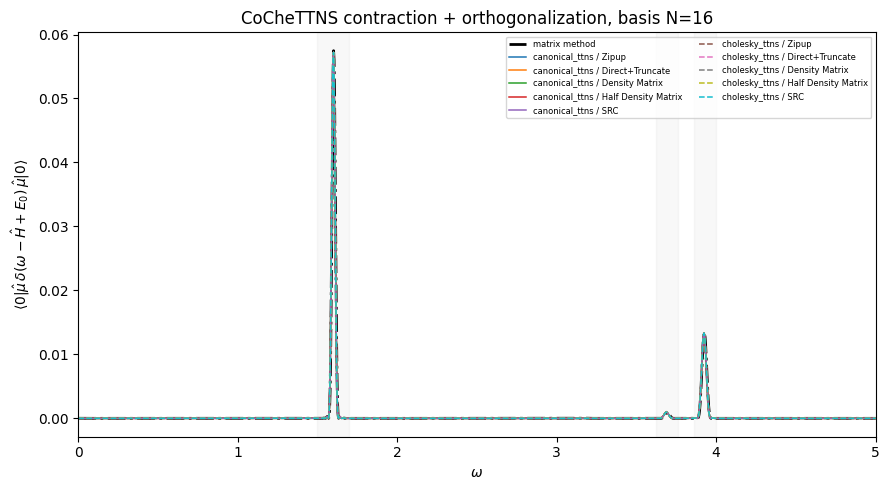

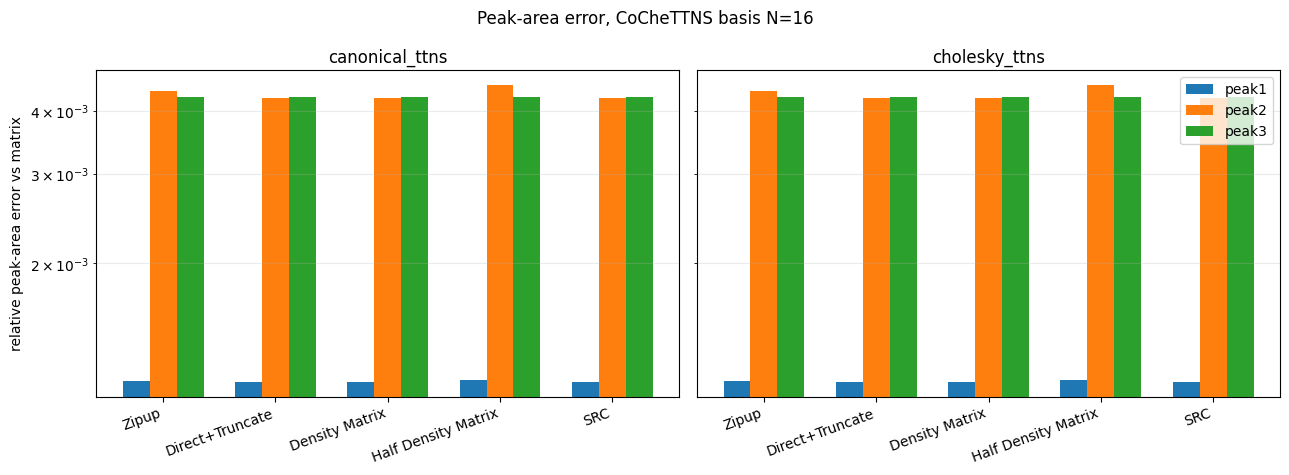

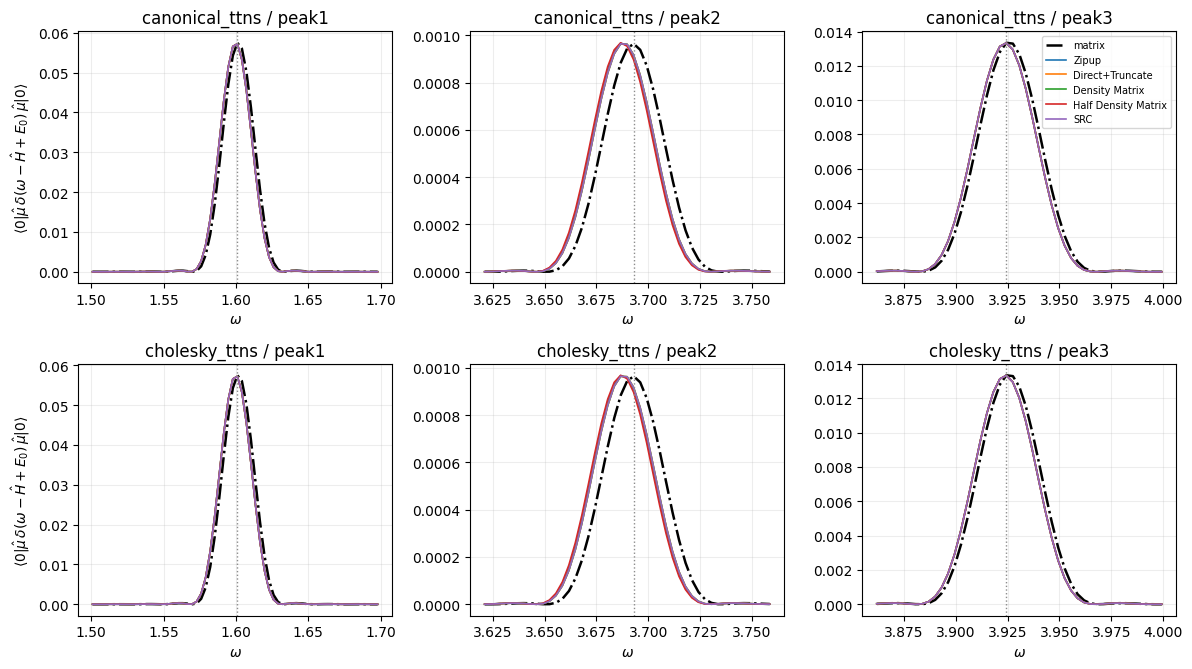

In [172]:
method_labels = {name: label for name, label, _ in CONTRACTION_METHODS}
orth_labels = {name: label for name, label, _ in ORTHOGONALIZATION_METHODS}
method_names = [name for name, _, _ in CONTRACTION_METHODS]
orth_names = [name for name, _, _ in ORTHOGONALIZATION_METHODS]
line_styles = {"canonical": "-", "cholesky": "--"}

plt.figure(figsize=(9, 5))
plt.plot(E_grid_matrix, vals_mat, color="black", linestyle="-.", linewidth=2, label="matrix method")
for orth_name in orth_names:
    for method_name in method_names:
        key = (orth_name, method_name)
        if key in contraction_spectra:
            plt.plot(
                E_grid,
                contraction_spectra[key],
                linewidth=1.1,
                linestyle=line_styles.get(orth_name, "-"),
                label=f"{orth_labels[orth_name]} / {method_labels[method_name]}",
            )
for ref_peak in matrix_peak_ref.values():
    plt.axvspan(ref_peak["search_left_x"], ref_peak["search_right_x"], color="0.75", alpha=0.10)
plt.xlim(0, 5)
plt.xlabel(r"$\omega$")
plt.ylabel(r"$\langle 0|\hat{\mu}\,\delta(\omega-\hat{H}+E_0)\,\hat{\mu}|0\rangle$")
plt.title(f"CoCheTTNS contraction + orthogonalization, basis N={cochet_basis_size}")
plt.legend(fontsize=6, ncol=2)
plt.tight_layout()
plt.show()

peaks = list(matrix_peak_ref.keys())
fig, axes = plt.subplots(1, len(orth_names), figsize=(6.5 * len(orth_names), 4.8), sharey=True)
if len(orth_names) == 1:
    axes = [axes]
for ax, orth_name in zip(axes, orth_names):
    x_pos = np.arange(len(method_names))
    width = 0.24
    for i, peak_name in enumerate(peaks):
        rel_vals = []
        for method_name in method_names:
            match = [
                row for row in contraction_peak_rows
                if row["orth"] == orth_name and row["method"] == method_name and row["peak"] == peak_name
            ]
            rel_vals.append(match[0]["rel_error"] if match else np.nan)
        ax.bar(x_pos + (i - 1) * width, rel_vals, width=width, label=peak_name)
    ax.set_yscale("log")
    ax.set_xticks(x_pos)
    ax.set_xticklabels([method_labels[name] for name in method_names], rotation=20, ha="right")
    ax.set_title(orth_labels[orth_name])
    ax.grid(True, axis="y", which="both", alpha=0.25)
axes[0].set_ylabel("relative peak-area error vs matrix")
axes[-1].legend()
fig.suptitle(f"Peak-area error, CoCheTTNS basis N={cochet_basis_size}")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(len(orth_names), len(matrix_peak_ref), figsize=(12, 3.4 * len(orth_names)), squeeze=False)
for row_idx, orth_name in enumerate(orth_names):
    for col_idx, (peak_name, ref_peak) in enumerate(matrix_peak_ref.items()):
        ax = axes[row_idx, col_idx]
        left_x = ref_peak["search_left_x"]
        right_x = ref_peak["search_right_x"]
        mask_mat = (E_grid_matrix >= left_x) & (E_grid_matrix <= right_x)
        ax.plot(E_grid_matrix[mask_mat], vals_mat[mask_mat], color="black", linestyle="-.", linewidth=1.8, label="matrix")
        mask_ttns = (E_grid >= left_x) & (E_grid <= right_x)
        for method_name in method_names:
            key = (orth_name, method_name)
            if key in contraction_spectra:
                ax.plot(E_grid[mask_ttns], contraction_spectra[key][mask_ttns], linewidth=1.2, label=method_labels[method_name])
        ax.axvline(ref_peak["peak_x"], color="0.55", linestyle=":", linewidth=1.0)
        ax.set_title(f"{orth_labels[orth_name]} / {peak_name}")
        ax.set_xlabel(r"$\omega$")
        ax.grid(True, alpha=0.22)
axes[0, 0].set_ylabel(r"$\langle 0|\hat{\mu}\,\delta(\omega-\hat{H}+E_0)\,\hat{\mu}|0\rangle$")
if len(orth_names) > 1:
    axes[1, 0].set_ylabel(r"$\langle 0|\hat{\mu}\,\delta(\omega-\hat{H}+E_0)\,\hat{\mu}|0\rangle$")
axes[0, -1].legend(fontsize=7, loc="upper right")
fig.tight_layout()
plt.show()
